# End-to-end EOS reweighting example

This notebook demonstrates the full `eos-reweighting` sampler pipeline in jester. Since the main benefit of this method is to reweigh *any* set of EOSs, we will demonstrate it using Gaussian process (GPR) EOSs. In particular, we will download and postprocess a set of GPR EOSs from Legred et al., PRD 104, 063003 (2021). The samples are available on [this Zenodo](https://zenodo.org/record/6502467) and referred to as LCEHL.

The outline of this example is as follows.
1. Download the Legred+2021 LCEHL EOS posterior samples from Zenodo (`PSR` and `PSR+GW+NICER` variants).
2. Convert the `PSR`-only release (broad prior, GW/NICER not yet folded in) into the NPZ format expected by the `eos-reweighting` sampler implemened in `jester`.
3. Run `run_jester_inference config.yaml`, which reweights the 10k `PSR` EOS samples using jester's GW170817 + NICER likelihoods.
4. Cross-validate the reweighted posterior against the `PSR+GW+NICER` reference release (an independent nonparametric inference using the same data), reproducing the diagnostic plots from `lwp_jester/postprocessing/check_validation.py`.

In [1]:
import shutil
import subprocess
import urllib.request
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

# Set up paths and directories
HERE = Path.cwd()
DATA_DIR = HERE / "data"
EOS_SETS_DIR = HERE / "eos_sets"
OUTDIR = HERE / "outdir"

DATA_DIR.mkdir(parents=True, exist_ok=True)
EOS_SETS_DIR.mkdir(parents=True, exist_ok=True)

## 1. Download the Zenodo EOS posterior samples

Two datasets from the Zenodo releases are needed for this example

- `PSR`: Only use radio pulsar masses. This is the **prior** we reweight with jester (so GW/NICER data is not double-counted).
- `PSR+GW+NICER`: Additionally conditioned on GW170817 + NICER. This is the **reference** we validate jester's reweighted posterior against.

Both files are cached in `data/` and gitignored -- the cell below only downloads what's missing.

In [2]:
PRIOR_TYPES = {
    "psr": {
        "url": (
            "https://zenodo.org/records/6502467/files/"
            "LCEHL_EOS_posterior_samples_PSR.h5?download=1"
        ),
        "filename": "LCEHL_EOS_posterior_samples_PSR.h5",
    },
    "psr-gw-nicer": {
        "url": (
            "https://zenodo.org/records/6502467/files/"
            "LCEHL_EOS_posterior_samples_PSR%2BGW%2BNICER.h5?download=1"
        ),
        "filename": "LCEHL_EOS_posterior_samples_PSR+GW+NICER.h5",
    },
}


def download_h5(h5_path: Path, url: str) -> None:
    print(f"Downloading {h5_path.name} from Zenodo...")

    def _progress(block_num, block_size, total_size):
        done = block_num * block_size
        if total_size > 0:
            pct = min(100, 100 * done // total_size)
            mb = done / 1e6
            print(f"\r  {pct:3d}%  {mb:.0f} MB", end="", flush=True)

    tmp = h5_path.with_suffix(".h5.tmp")
    urllib.request.urlretrieve(url, tmp, reporthook=_progress)
    tmp.rename(h5_path)
    print(f"\nSaved to {h5_path}")


def get_or_download(prior_type: str) -> Path:
    info = PRIOR_TYPES[prior_type]
    h5_path = DATA_DIR / info["filename"]
    if h5_path.exists():
        print(f"Already downloaded: {h5_path}")
    else:
        download_h5(h5_path, info["url"])
    return h5_path


psr_h5 = get_or_download("psr")
target_h5 = get_or_download("psr-gw-nicer")


Already downloaded: /Users/Woute029/Documents/Code/projects/38_lwp_jester/jester/docs/examples/inference/reweighting/data/LCEHL_EOS_posterior_samples_PSR.h5
Already downloaded: /Users/Woute029/Documents/Code/projects/38_lwp_jester/jester/docs/examples/inference/reweighting/data/LCEHL_EOS_posterior_samples_PSR+GW+NICER.h5


## 2. Convert to the NPZ format expected by the `eos-reweighting` sampler

The sampler requires NPZ files with `masses`, `lambdas`, `radii` arrays of shape `[N_eos, n_grid]` on a common mass grid (see `EOSReweightingConfig` docstring in `jesterTOV/inference/config/schemas/samplers.py`). We resample each LCEHL M-R-Lambda curve onto a shared grid, following `lwp_jester/first_runs/scripts/convert_lcehl_to_npz.py`.


In [3]:
def load_lcehl_curves(
    h5_path: Path,
    n_eos: int | None = None,
    m_min: float = 0.5,
    n_grid: int = 200,
) -> dict[str, np.ndarray]:
    """Load M-R-Lambda curves from a LCEHL HDF5 file, resampled to a common grid."""
    with h5py.File(h5_path, "r") as f:
        ns_keys = sorted(f["ns"].keys(), key=lambda k: int(k.split("_")[1]))
        if n_eos is not None:
            ns_keys = ns_keys[:n_eos]

        masses_raw, lambdas_raw, radii_raw, m_tov_list = [], [], [], []
        for key in ns_keys:
            curve = f[f"ns/{key}"][()]
            m = curve["M"].astype(np.float64)
            r = curve["R"].astype(np.float64)
            lam = curve["Lambda"].astype(np.float64)

            m_tov = float(m.max())
            if m_tov <= m_min:
                continue

            masses_raw.append(m)
            lambdas_raw.append(lam)
            radii_raw.append(r)
            m_tov_list.append(m_tov)

    m_max_grid = float(np.min(m_tov_list))
    mass_grid = np.linspace(m_min, m_max_grid, n_grid)
    print(f"  Common mass grid: [{m_min:.2f}, {m_max_grid:.3f}] M_sun ({n_grid} pts)")
    print(f"  Loaded {len(masses_raw)} EOS curves")

    lam_grid = np.zeros((len(masses_raw), n_grid), dtype=np.float64)
    rad_grid = np.zeros((len(masses_raw), n_grid), dtype=np.float64)

    for i, (m, lam, r, m_tov) in enumerate(
        zip(masses_raw, lambdas_raw, radii_raw, m_tov_list)
    ):
        order = np.argsort(m)
        m, lam, r = m[order], lam[order], r[order]

        lam_g = np.interp(mass_grid, m, lam, left=0.0, right=0.0)
        rad_g = np.interp(mass_grid, m, r, left=0.0, right=0.0)
        above = mass_grid > m_tov
        lam_g[above] = 0.0
        rad_g[above] = 0.0
        lam_grid[i] = lam_g
        rad_grid[i] = rad_g

    masses_stacked = np.broadcast_to(mass_grid, (len(masses_raw), n_grid)).copy()
    return {"masses": masses_stacked, "lambdas": lam_grid, "radii": rad_grid}


def get_or_convert(h5_path: Path, npz_path: Path) -> Path:
    if npz_path.exists():
        print(f"Already converted: {npz_path}")
        return npz_path
    print(f"Converting {h5_path.name} -> {npz_path.name} ...")
    data = load_lcehl_curves(h5_path, m_min=1.1, n_grid=200)
    np.savez(npz_path, **data)
    print(f"  Saved to {npz_path}")
    return npz_path


psr_npz = get_or_convert(psr_h5, EOS_SETS_DIR / "PSR_10k.npz")
target_npz = get_or_convert(target_h5, EOS_SETS_DIR / "PSR_GW_NICER_10k.npz")


Already converted: /Users/Woute029/Documents/Code/projects/38_lwp_jester/jester/docs/examples/inference/reweighting/eos_sets/PSR_10k.npz
Already converted: /Users/Woute029/Documents/Code/projects/38_lwp_jester/jester/docs/examples/inference/reweighting/eos_sets/PSR_GW_NICER_10k.npz


## 3. Run jester's EOS reweighting

`config.yaml` (in this directory) reweights `eos_sets/PSR_10k.npz` with jester's GW170817 + NICER (J0030, J0740+6620) likelihoods. `run_jester_inference` resolves all config paths relative to the current working directory, so it must be run from this directory.


In [4]:
result_path = OUTDIR / "result.h5"

subprocess.run(
    ["run_jester_inference", "config.yaml"],
    cwd=HERE,
    check=True,
)

assert result_path.exists(), f"Expected result file not found: {result_path}"
print(f"Result written to {result_path}")

[INFO] jester: jesterTOV version 0.2.2 (git c17c0d5)
[INFO] jester: EOS reweighting mode — loading config from config.yaml
[INFO] jester: Output directory: outdir
[INFO] jester: JAX devices: [CpuDevice(id=0)]
[INFO] jester: Checking to prepare GW normalizing flows...
[INFO] jester: Creating combined likelihood...
[WARNING] jester: No nf_model_dir provided for event 'GW170817'. Using default preset path: /Users/Woute029/Documents/Code/projects/38_lwp_jester/jester/jesterTOV/inference/flows/models/gw_maf/gw170817/gw170817_gwtc1_lowspin
[INFO] jester: Loading NF model for GW170817 from /Users/Woute029/Documents/Code/projects/38_lwp_jester/jester/jesterTOV/inference/flows/models/gw_maf/gw170817/gw170817_gwtc1_lowspin


[INFO] jester: Loaded NF model for GW170817
[INFO] jester: Pre-sampling 2000 mass pairs with seed=42 for GW170817


[INFO] jester: Pre-sampled mass range: m1=[1.361, 1.752] Msun, m2=[1.074, 1.371] Msun
[INFO] jester: Loading Amsterdam flow for J0030 from ../../../../jesterTOV/inference/flows/models/nicer_maf/J00300451/amsterdam_st_pst


[INFO] jester: Pre-sampled Amsterdam mass range: [1.022, 1.679] Msun
Amsterdam flow loaded for J0030. Pre-sampled mass range: [1.022, 1.679] Msun
[INFO] jester: Loading Maryland flow for J0030 from ../../../../jesterTOV/inference/flows/models/nicer_maf/J00300451/maryland_2spot_rm


[INFO] jester: Pre-sampled Maryland mass range: [1.115, 1.946] Msun
Maryland flow loaded for J0030. Pre-sampled mass range: [1.115, 1.946] Msun
[INFO] jester: Loaded 2 normalizing flow(s) for J0030
[INFO] jester: Loading Amsterdam flow for J0740+6620 from ../../../../jesterTOV/inference/flows/models/nicer_maf/J07406620/amsterdam_gamma_nicerxmm


...

[INFO] jester: EOS reweighting: 1000/10000 EOS (10%) | elapsed 1.7s | ETA 15.2s
[INFO] jester: EOS reweighting: 2000/10000 EOS (20%) | elapsed 1.7s | ETA 6.7s
[INFO] jester: EOS reweighting: 3000/10000 EOS (30%) | elapsed 1.7s | ETA 3.9s
[INFO] jester: EOS reweighting: 4000/10000 EOS (40%) | elapsed 1.7s | ETA 2.5s
[INFO] jester: EOS reweighting: 5000/10000 EOS (50%) | elapsed 1.7s | ETA 1.7s
[INFO] jester: EOS reweighting: 6000/10000 EOS (60%) | elapsed 1.7s | ETA 1.1s
[INFO] jester: EOS reweighting: 7000/10000 EOS (70%) | elapsed 1.7s | ETA 0.7s
[INFO] jester: EOS reweighting: 8000/10000 EOS (80%) | elapsed 1.7s | ETA 0.4s


[INFO] jester: EOS reweighting: 9000/10000 EOS (90%) | elapsed 4.5s | ETA 0.5s


[INFO] jester: EOS reweighting: 10000/10000 EOS (100%) | elapsed 7.0s | ETA 0.0s
[INFO] jester: EOS reweighting: all EOS processed in 7.1s


[INFO] jester: log Z = -15.592 ± 0.015  N_eff = 3097.5 (31.0%)
[INFO] jester: EOS reweighting finished in 26.1s
[INFO] jester: Saving inference results to outdir/result.h5
[INFO] jester: Successfully saved results to outdir/result.h5
[INFO] jester: Results saved to outdir/result.h5


Result written to /Users/Woute029/Documents/Code/projects/38_lwp_jester/jester/docs/examples/inference/reweighting/outdir/result.h5


## 4. Cross-validate against the PSR+GW+NICER reference

Reproduces the diagnostics and plots from `lwp_jester/postprocessing/check_validation.py`: an M-R credible-band comparison and 1-D marginals of $R(1.4\,M_\odot)$ and $\Lambda(1.4\,M_\odot)$, comparing the `PSR` prior, jester's reweighted posterior, and the `PSR+GW+NICER` reference.


In [5]:
fs = 16
params = {
    "axes.grid": False,
    "text.usetex": shutil.which("latex") is not None,
    "font.family": "serif",
    "ytick.color": "black",
    "xtick.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "xtick.labelsize": fs,
    "ytick.labelsize": fs,
    "axes.labelsize": fs,
    "font.serif": ["Computer Modern Serif"],
}
plt.rcParams.update(params)


# FIXME: do this with jester tools instead
def load_result(path: Path) -> dict:
    with h5py.File(path, "r") as f:
        return {
            "eos_index": f["posterior/parameters/eos_index"][:],
            "log_likelihood": f["posterior/parameters/log_likelihood"][:],
            "posterior_weight": f["posterior/parameters/posterior_weight"][:],
            "log_prob": f["posterior/log_prob"][:],
        }

# FIXME: again with jester tools instead
def load_eos_set(path: Path) -> dict:
    d = np.load(path)
    return {"masses": d["masses"], "radii": d["radii"], "lambdas": d["lambdas"]}

def weighted_quantiles(values, weights, quantiles):
    sort_idx = np.argsort(values)
    values_sorted = values[sort_idx]
    weights_sorted = weights[sort_idx]
    cumsum = np.cumsum(weights_sorted)
    cumsum /= cumsum[-1]
    return np.interp(quantiles, cumsum, values_sorted)


def mr_band(radii, weights=None, q_lo=0.05, q_hi=0.95):
    """Plots bands in the mass-radius plane"""
    n_grid = radii.shape[1]
    if weights is None:
        weights = np.ones(len(radii)) / len(radii)
    median, lo, hi = np.empty(n_grid), np.empty(n_grid), np.empty(n_grid)
    for j in range(n_grid):
        median[j], lo[j], hi[j] = weighted_quantiles(
            radii[:, j], weights, [0.5, q_lo, q_hi]
        )
    return median, lo, hi

def interp_at_mass(masses_grid, values, m_target):
    """Quick interpolation method"""
    idx = np.searchsorted(masses_grid, m_target)
    if idx == 0 or idx >= len(masses_grid):
        raise ValueError(
            f"m_target={m_target} outside grid [{masses_grid[0]:.2f}, {masses_grid[-1]:.2f}]"
        )
    m_lo, m_hi = masses_grid[idx - 1], masses_grid[idx]
    t = (m_target - m_lo) / (m_hi - m_lo)
    return (1 - t) * values[:, idx - 1] + t * values[:, idx]


result = load_result(result_path)
prior = load_eos_set(psr_npz)
ref = load_eos_set(target_npz)

In [6]:
# Load the results
pw = result["posterior_weight"]
lw = result["log_likelihood"]
n = len(pw)
finite_lw = lw[np.isfinite(lw)]

mass_grid = prior["masses"][0]
eos_idx = result["eos_index"]

R14_prior = interp_at_mass(mass_grid, prior["radii"], 1.4)
L14_prior = interp_at_mass(mass_grid, prior["lambdas"], 1.4)
R14_post = R14_prior[eos_idx]
L14_post = L14_prior[eos_idx]

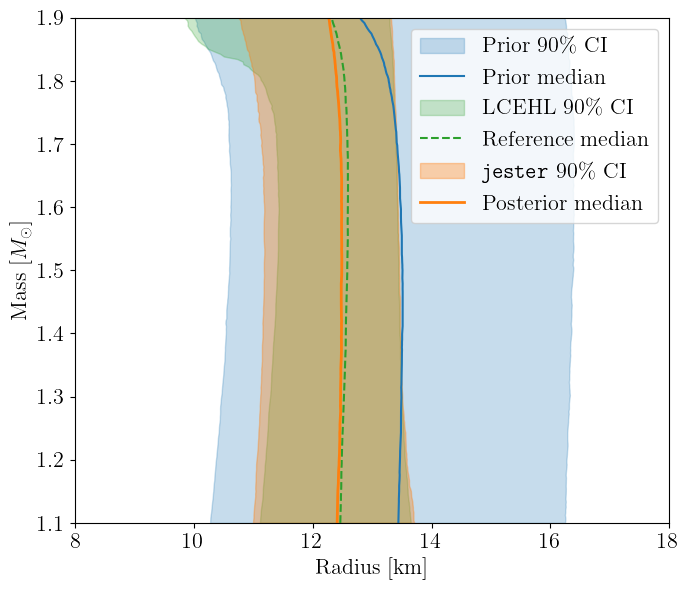

In [7]:
# Plot the results
prior_masses = prior["masses"][0]
ref_masses = ref["masses"][0]

p_med, p_lo, p_hi = mr_band(prior["radii"])
post_radii = prior["radii"][eos_idx]
w_post = pw / pw.sum()
pp_med, pp_lo, pp_hi = mr_band(post_radii, weights=w_post)
r_med, r_lo, r_hi = mr_band(ref["radii"])

fig, ax = plt.subplots(figsize=(7, 6))

ax.fill_betweenx(prior_masses, p_lo, p_hi, alpha=0.25, color="tab:blue", label=r"Prior 90\% CI")
ax.plot(p_med, prior_masses, color="tab:blue", lw=1.5, label="Prior median")

ax.fill_betweenx(ref_masses, r_lo, r_hi, alpha=0.25, color="tab:green", label=r"LCEHL 90\% CI")
ax.plot(r_med, ref_masses, color="tab:green", lw=1.5, ls="--", label="Reference median")

ax.fill_betweenx(prior_masses, pp_lo, pp_hi, alpha=0.35, color="tab:orange", label=r"\texttt{jester} 90\% CI")
ax.plot(pp_med, prior_masses, color="tab:orange", lw=2.0, label="Posterior median")

ax.set_xlabel("Radius [km]", fontsize=fs)
ax.set_ylabel(r"Mass [$M_\odot$]", fontsize=fs)
ax.legend(fontsize=fs)
ax.set_xlim(8, 18)
ax.set_ylim(1.1, 1.9)

fig.tight_layout()
plt.show()

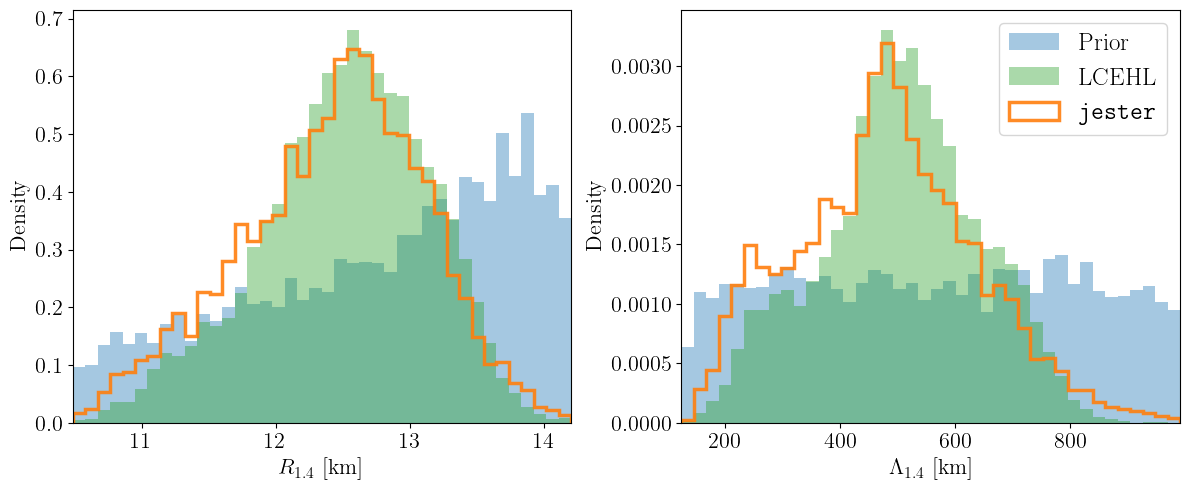

In [8]:
# Also plot histograms of the radius and tidal deformability at 1.4 solar masses
R14_ref = interp_at_mass(ref_masses, ref["radii"], 1.4)
L14_ref = interp_at_mass(ref_masses, ref["lambdas"], 1.4)

quantities = [
    (r"$R_{1.4}$ [km]", R14_prior, R14_post, R14_ref),
    (r"$\Lambda_{1.4}$ [km]", L14_prior, L14_post, L14_ref),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
kw_bins = 40

for ax, (label, q_prior, q_post, q_ref) in zip(axes, quantities):
    ci_lo, ci_hi = weighted_quantiles(q_post, pw, [0.005, 0.995])
    pad = 0.05 * (ci_hi - ci_lo)
    vmin, vmax = ci_lo - pad, ci_hi + pad
    bins = np.linspace(vmin, vmax, kw_bins + 1)

    ax.hist(q_prior, bins=bins, density=True, alpha=0.4, color="tab:blue", label="Prior")
    ax.hist(q_ref, bins=bins, density=True, alpha=0.4, color="tab:green", label="LCEHL")
    ax.hist(
        q_post,
        bins=bins,
        weights=pw,
        density=True,
        alpha=0.9,
        color="tab:orange",
        histtype="step",
        lw=2.5,
        label=r"\texttt{jester}",
    )

    ax.set_xlim(vmin, vmax)
    ax.set_xlabel(label, fontsize=fs)
    ax.set_ylabel("Density", fontsize=fs)
    if ax == axes[-1]:
        ax.legend(fontsize=18)

fig.tight_layout()
plt.show()

## Conclusion

We managed to replicate the GW+NICER results from the LCEHL paper using their publicly available prior Gaussian process EOS samples, using the built-in `jester` GW and NICER likelihoods. The match is not perfect, since we might be using different datasets for the GW and NICER posteriors due to updated posteriors samples since the LCEHL Zenodo dataset was released, as well as small differences in the numerical implementation of the GW and NICER likelihoods (e.g., using a KDE versus a normalizing flow to approximate the densities, etc). Given this, the small difference in the result is to be expected, and we can conclude that `jester` can be used for EOS reweighing alongside the direct EOS sampling!